In [61]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()

True

In [62]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    strike_rate: float
    balls_per_boundary: float
    boundary_percentage: float

In [63]:
def strike_rate(state: BatsmanState):
    sr = (100 * state['runs']) / state['balls']
    # sr = 100
    return {'strike_rate': sr}

In [64]:
def balls_per_boundary(state: BatsmanState):
    bpb =  (state['fours'] + state['sixes'] ) * 100 / state['balls']
    return {'balls_per_boundary': bpb}



In [65]:
def boundary_percentage(state: BatsmanState):
    bp =  (state['fours'] * 4 + state['sixes'] * 6) * 100 / state['runs']
    return {'boundary_percentage': bp}

In [66]:
def summary(state: BatsmanState):
    summary = f"The batsman scored {state['runs']} runs off {state['balls']} balls with a strike rate of {state['strike_rate']:.2f}. He hit {state['fours']} fours and {state['sixes']} sixes, resulting in a boundary percentage of {state['boundary_percentage']:.2f}% and a balls per boundary ratio of {state['balls_per_boundary']:.2f}."
    return {'summary': summary}

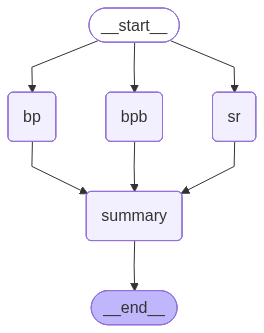

In [67]:
graph = StateGraph(BatsmanState)

graph.add_node("bpb",balls_per_boundary)
graph.add_node("bp",boundary_percentage)
graph.add_node("sr",strike_rate)
graph.add_node("summary",summary)

graph.add_edge(START, "bpb")
graph.add_edge(START, "bp")
graph.add_edge(START, "sr")



graph.add_edge("bpb", "summary")
graph.add_edge("bp", "summary")
graph.add_edge("sr", "summary")

graph.add_edge("summary", END)

workflow = graph.compile()

workflow

In [68]:

initial_state: BatsmanState = {
    'runs': 150,
    'balls': 120,
    'fours': 10,
    'sixes': 5
}

final_state = workflow.invoke(initial_state)
final_state



{'runs': 150,
 'balls': 120,
 'fours': 10,
 'sixes': 5,
 'strike_rate': 125.0,
 'balls_per_boundary': 12.5,
 'boundary_percentage': 46.666666666666664}